# Make plot of Beaufort Sea domain showing mean FWC in upper 10m

In [2]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import time
import cartopy.crs as ccrs
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:34567")
client

<Client: 'tcp://127.0.0.1:34567' processes=7 threads=28, memory=108.45 GiB>

In [3]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [6]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [7]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [124]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [125]:
salt_beaufort = salt_da.isel(i=slice(450,800),j=slice(0,500),k=slice(0,7))
ice_beaufort = ice_da.isel(i=slice(450,800),j=slice(0,500))

In [96]:
# HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.mask_basin.isel(k=0)!=0).isel(i=slice(450,700),j=slice(0,500))
HH_grid_land = 1 - HH_grid.mask_basin.isel(k=0,i=slice(450,800),j=slice(0,500)).where(HH_grid.mask_basin.isel(k=0,i=slice(450,800),j=slice(0,500))==0)
land_rot = xr.DataArray(np.rot90(HH_grid_land,3), dims=['i','j'])

## Calculate FWC

In [97]:
def calculate_fwc(salt_da, salt_ref, dz):
    """
    Calculate the freshwater content (fwc)

    Parameters:
    salt_da (xr.DataArray): Salinity data array with a 'k' dimension.
    salt_ref (float): Reference salinity value.
    dz (xr.DataArray): Layer thickness data array with the same 'k' dimension.

    Returns:
    xr.DataArray: Freshwater content summed over the 'k' dimension.
    """
    fwc = ((salt_ref - salt_da) / salt_ref * dz).sum(dim='k')
    return fwc

In [98]:
salt_beaufort.Z.values

array([-0.5  , -1.57 , -2.79 , -4.185, -5.78 , -7.595, -9.66 ],
      dtype=float32)

In [99]:
# calculate FWC

# define reference salinity
salt_ref = 34.8

dz = HH_grid.isel(i=slice(450,800),j=slice(0,500)).drF.isel(k=slice(0,7)) # upper 10
fwc_beaufort = calculate_fwc(salt_beaufort, salt_ref, dz)

In [100]:
fwc_over_2m = fwc_yrs_masked.where(fwc_yrs_masked>2)
fwc_under_2m = fwc_yrs_masked.where(fwc_yrs_masked<2)

In [101]:
fwc_sep = fwc_beaufort.sel(time=fwc_beaufort['time'].dt.month == 9).mean(dim=['time'])
fwc_oct = fwc_beaufort.sel(time=fwc_beaufort['time'].dt.month == 10).mean(dim=['time'])
fwc_nov = fwc_beaufort.sel(time=fwc_beaufort['time'].dt.month == 11).mean(dim=['time'])

In [102]:
# rotate array
fwc_sep_flip = xr.DataArray(np.rot90(fwc_sep,3), dims=['i','j'])
fwc_oct_flip = xr.DataArray(np.rot90(fwc_oct,3), dims=['i','j'])
fwc_nov_flip = xr.DataArray(np.rot90(fwc_nov,3), dims=['i','j'])

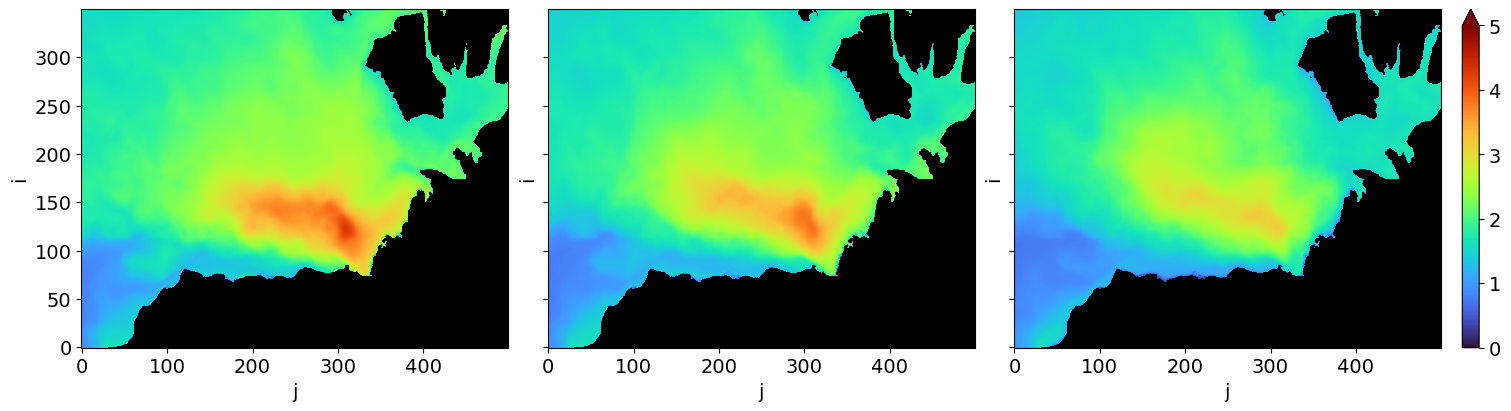

In [103]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,sharex=True,layout='constrained',figsize=[15,4])

fwc_sep_flip.plot(ax=ax1,vmin=0,vmax=5,cmap='turbo',add_colorbar=False)
fwc_oct_flip.plot(ax=ax2,vmin=0,vmax=5,cmap='turbo',add_colorbar=False)
fwc_nov_flip.plot(ax=ax3,vmin=0,vmax=5,cmap='turbo');

for ax in (ax1,ax2,ax3):
    land_rot.plot(ax=ax,vmin=0,vmax=1,cmap='Greys',add_colorbar=False)

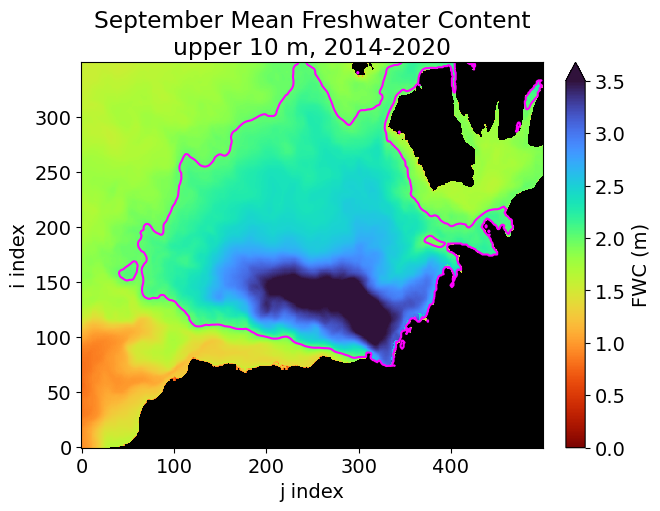

In [120]:
# draw a box for the Beaufort domain region
plt.rcParams['font.size'] = 14
fig, ax1 = plt.subplots(1,1,layout='constrained',figsize=[6.5,5])

fwc_sep_flip.plot(ax=ax1,vmin=0,vmax=3.5,cmap='turbo_r',cbar_kwargs={'label':'FWC (m)'})
fwc_sep_flip.plot.contour(ax=ax1,levels=[2],colors='magenta')
land_rot.plot(ax=ax1,vmin=0,vmax=1,cmap='Greys',add_colorbar=False)
ax1.set_ylabel('i index')
ax1.set_xlabel('j index')
ax1.set_title('September Mean Freshwater Content\nupper 10 m, 2014-2020');

### Add SIC contour

In [141]:
ice_sep = ice_beaufort.sel(time=ice_beaufort['time'].dt.month == 9).mean(dim=['time'])
# rotate array
ice_sep_flip = xr.DataArray(np.rot90(ice_sep,3), dims=['i','j'])

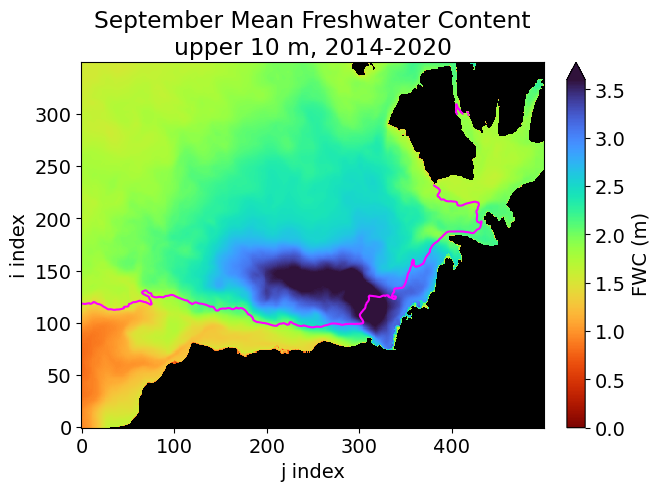

In [142]:
# draw a box for the Beaufort domain region
plt.rcParams['font.size'] = 14
fig, ax1 = plt.subplots(1,1,layout='constrained',figsize=[6.5,4.8])

fwc_sep_flip.plot(ax=ax1,vmin=0,vmax=3.6,cmap='turbo_r',cbar_kwargs={'label':'FWC (m)'})
ice_sep_flip.plot.contour(ax=ax1,levels=[15],colors='magenta')
land_rot.plot(ax=ax1,vmin=0,vmax=1,cmap='Greys',add_colorbar=False)
ax1.set_ylabel('i index')
ax1.set_xlabel('j index')
ax1.set_title('September Mean Freshwater Content\nupper 10 m, 2014-2020');

### Add SIC contour

In [157]:
fwc_sep = fwc_beaufort.sel(time='2020-09-06').isel(time=0)
# rotate array
fwc_sep_flip = xr.DataArray(np.rot90(fwc_sep,3), dims=['i','j'])

In [158]:
ice_sep = ice_beaufort.sel(time='2020-09-06').isel(time=0)
# rotate array
ice_sep_flip = xr.DataArray(np.rot90(ice_sep,3), dims=['i','j'])

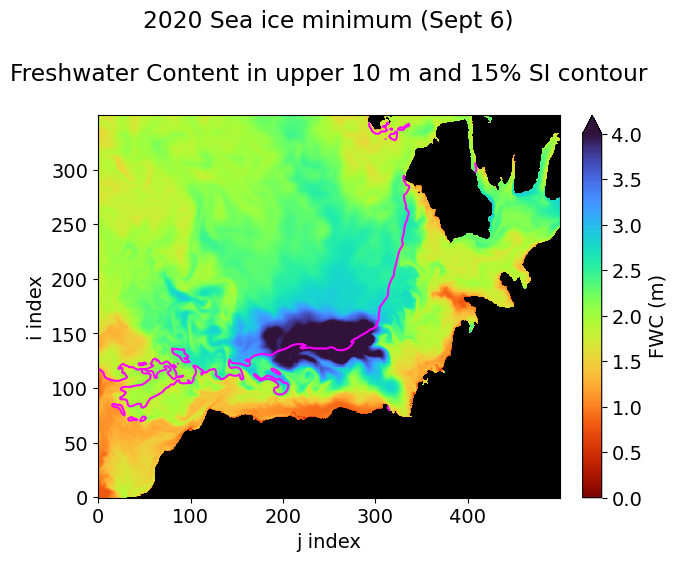

In [168]:
# draw a box for the Beaufort domain region
plt.rcParams['font.size'] = 14
fig, ax1 = plt.subplots(1,1,layout='constrained',figsize=[6.5,5.5])

fwc_sep_flip.plot(ax=ax1,vmin=0,vmax=4,cmap='turbo_r',cbar_kwargs={'label':'FWC (m)'})
ice_sep_flip.plot.contour(ax=ax1,levels=[15],colors='magenta')
land_rot.plot(ax=ax1,vmin=0,vmax=1,cmap='Greys',add_colorbar=False)
ax1.set_ylabel('i index')
ax1.set_xlabel('j index')
ax1.set_title('2020 Sea ice minimum (Sept 6)\n\nFreshwater Content in upper 10 m and 15% SI contour\n');